# SpatialAlign Tutorial

This notebook walks through the full SpatialAlign pipeline for cell-type annotation in subcellular spatial transcriptomics (SST) data, using the NSCLC (NanoString CosMx) example.

**Pipeline overview:**
1. **Stage 1** — Pretrain a DNN on reference scRNA-seq; assign initial pseudo-labels to SST cells
2. **Pseudo-label inference** — Use the trained model to predict cell types
3. **Stage 2** — Learn context-aware embeddings with GAT; refine pseudo-labels via prototype-guided contrastive alignment + UOT

**Prerequisites:** Download example data from [Data/Note.md](Data/Note.md) and place files in `data/`.

In [25]:
import sys
import os

# Add project root to path (run notebook from SpatialAlign/ directory)
sys.path.insert(0, os.getcwd())
from SpatialAlign import train_model, pseudoing_label, train_for_stage2

import scanpy as sc
import numpy as np
import pandas as pd


## 1. Setup and configuration

Set paths for input data and output checkpoints. Modify these to match your local setup.

In [26]:
# Path configuration — modify these to match your data locations
adata_sc_path = "data/sc_nsclc.h5ad"  # scRNA-seq reference
adata_st_path = "data/lung9_rep1_15types.h5ad"  # spatial transcriptomics target

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

model_save_path = os.path.join(output_dir, "mlp_stage1.pt")
gat_pt_path = os.path.join(output_dir, "gat_st.pt")
mlp_stage2_save_path = model_save_path

# Pre-computed UMAP (optional, for visualization)
umap_csv_path = "data/X_umap_df.csv"  # set to None if not available


## 2. Stage 1: Pretrain DNN on scRNA-seq

Train a supervised classifier on reference scRNA-seq data. The model learns cell-type prototypes and produces gene-aligned `adata_sc` and `adata_st`.

In [27]:
# Stage 1: train scRNA-seq classifier; returns aligned adata_sc and adata_st
adata_sc, adata_st, prototypes = train_model(
    adata_sc_path,
    adata_st_path,
    model_save_path,
)
adata_st

Epoch 1/7 | Loss: 122.9504 (cls 122.9504  | Train Acc: 0.3356 | Val Acc: 0.1501
Epoch 2/7 | Loss: 92.0118 (cls 92.0118  | Train Acc: 0.5432 | Val Acc: 0.6568
Epoch 3/7 | Loss: 60.5125 (cls 60.5125  | Train Acc: 0.7375 | Val Acc: 0.6857
Epoch 4/7 | Loss: 38.8334 (cls 38.8334  | Train Acc: 0.8272 | Val Acc: 0.7047
Epoch 5/7 | Loss: 25.8135 (cls 25.8135  | Train Acc: 0.8765 | Val Acc: 0.7073
Epoch 6/7 | Loss: 19.6163 (cls 19.6163  | Train Acc: 0.8958 | Val Acc: 0.7083
Epoch 7/7 | Loss: 16.0975 (cls 16.0975  | Train Acc: 0.9099 | Val Acc: 0.7051
Label: B-cell, Prototype: [ 4.3261930e-01  1.3397107e-02 -7.5258583e-02  1.3393619e+00
  3.3624415e+00  2.3730110e-01  1.1896561e+00  1.3722967e-01
  2.7072370e-01 -4.1248284e-02  6.9558388e-01  1.4236201e+00
 -4.2026900e-02  1.7782327e+00 -6.9390647e-02  6.6833001e-01
  2.7826617e+00 -1.1089464e-01  1.2087959e+00  3.6455188e+00
 -1.2159431e-01  5.5568647e+00  4.0676460e+00 -9.2595577e-02
  3.8731592e+00  2.1737723e+00  2.8892386e-01  3.2770576e+00

AnnData object with n_obs × n_vars = 85904 × 952
    obs: 'fov', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'celltype'
    uns: 'log1p'
    obsm: 'spatial'

In [28]:
# Pseudo-label inference using Stage 1 model
adata_st = pseudoing_label(adata_st, model_save_path)
adata_st

Filtered Accuracy: 0.7083
              precision    recall  f1-score   support

          NK     0.4800    0.0483    0.0877       746
        Treg     0.3421    0.1545    0.2128      1269
         mDC     0.0000    0.0000    0.0000       994
 plasmablast     0.7010    0.5036    0.5861      2895
      tumors     0.8231    0.9474    0.8809     39422
      B-cell     0.3456    0.3892    0.3661       871
  epithelial     0.3440    0.4088    0.3736      3584
  neutrophil     0.7306    0.0237    0.0459      5948
 endothelial     0.6452    0.5799    0.6108      4428
  fibroblast     0.6168    0.9794    0.7569     13952
  macrophage     0.6221    0.7522    0.6810      4080
         pDC     0.2857    0.0075    0.0146      1065
        mast     0.7653    0.2577    0.3856       291
       T CD8     0.5021    0.1042    0.1725      2323
       T CD4     0.3396    0.0580    0.0990      4036

    accuracy                         0.7083     85904
   macro avg     0.5029    0.3476    0.3516     85904


AnnData object with n_obs × n_vars = 85904 × 952
    obs: 'fov', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'celltype', 'pseudo_label', 'pseudo_confidence'
    uns: 'log1p'
    obsm: 'spatial'

## 3. Pseudo-label inference

Use the Stage 1 model to assign initial pseudo-labels and confidence scores to SST cells.

In [29]:
# Stage 1 evaluation metrics (requires ground truth)
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    classification_report,
    f1_score,
)

y_true = adata_st.obs["celltype"].astype(str)
y_pred = adata_st.obs["pseudo_label"].astype(str)

acc = accuracy_score(y_true, y_pred)
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
ami = adjusted_mutual_info_score(y_true, y_pred)
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
report = classification_report(y_true, y_pred, digits=4)

print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print(f"ARI: {ari:.4f}")
print(f"AMI: {ami:.4f}")
print(f"NMI: {nmi:.4f}")
print("Classification report:\n", report)

Accuracy: 0.7083
Weighted F1: 0.6480
ARI: 0.6143
AMI: 0.4611
NMI: 0.4615
Classification report:
               precision    recall  f1-score   support

      B-cell     0.3456    0.3892    0.3661       871
          NK     0.4800    0.0483    0.0877       746
       T CD4     0.3396    0.0580    0.0990      4036
       T CD8     0.5021    0.1042    0.1725      2323
        Treg     0.3421    0.1545    0.2128      1269
 endothelial     0.6452    0.5799    0.6108      4428
  epithelial     0.3440    0.4088    0.3736      3584
  fibroblast     0.6168    0.9794    0.7569     13952
         mDC     0.0000    0.0000    0.0000       994
  macrophage     0.6221    0.7522    0.6810      4080
        mast     0.7653    0.2577    0.3856       291
  neutrophil     0.7306    0.0237    0.0459      5948
         pDC     0.2857    0.0075    0.0146      1065
 plasmablast     0.7010    0.5036    0.5861      2895
      tumors     0.8231    0.9474    0.8809     39422

    accuracy                         

### Stage 1 metrics (optional)

Evaluate pseudo-label quality against ground truth if available.

In [30]:
# Save Stage 1 pseudo-labels (optional); backup for plotting (Stage 2 overwrites pseudo_label)
adata_st.obs["pseudo_label"].to_csv(os.path.join(output_dir, "stage1_pseudo_label.csv"))
adata_st.obs["pseudo_label_stage1"] = adata_st.obs["pseudo_label"].astype(str)

In [31]:
# Attach pre-computed UMAP coordinates (optional)
if umap_csv_path and os.path.exists(umap_csv_path):
    umap_df = pd.read_csv(umap_csv_path, index_col=0)
    shared = adata_st.obs_names.intersection(umap_df.index)
    adata_st = adata_st[shared].copy()
    adata_st.obsm["X_umap"] = umap_df.loc[shared, ["UMAP1", "UMAP2"]].to_numpy()
adata_st

AnnData object with n_obs × n_vars = 85904 × 952
    obs: 'fov', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'celltype', 'pseudo_label', 'pseudo_confidence', 'pseudo_label_stage1'
    uns: 'log1p'
    obsm: 'spatial', 'X_umap'

### Optional: Attach UMAP coordinates

Pre-computed UMAP coordinates enable downstream visualization. Skip if `X_umap_df.csv` is not available.

In [32]:
# Stage 2: train spatial encoder (GAT) with pseudo-labels
adata_st = train_for_stage2(
    model_save_path,
    adata_sc,
    adata_st,
    gat_pt_path,
    mlp_stage2_save_path,
)
adata_st


===== Epoch 1 pseudo_confidence stats by class =====
Class          B-cell | n=   981 | mean=0.513, std=0.234, p25=0.318, p50=0.470, p75=0.699, min=0.116, max=0.991
Class              NK | n=    75 | mean=0.451, std=0.206, p25=0.317, p50=0.425, p75=0.570, min=0.113, max=0.960
Class           T CD4 | n=   689 | mean=0.499, std=0.203, p25=0.332, p50=0.484, p75=0.645, min=0.106, max=0.963
Class           T CD8 | n=   482 | mean=0.563, std=0.236, p25=0.368, p50=0.533, p75=0.767, min=0.125, max=0.997
Class            Treg | n=   573 | mean=0.439, std=0.193, p25=0.295, p50=0.409, p75=0.546, min=0.101, max=0.986
Class     endothelial | n=  3980 | mean=0.642, std=0.272, p25=0.398, p50=0.657, p75=0.918, min=0.101, max=1.000
Class      epithelial | n=  4259 | mean=0.577, std=0.212, p25=0.413, p50=0.565, p75=0.741, min=0.105, max=0.998
Class      fibroblast | n= 22154 | mean=0.839, std=0.219, p25=0.725, p50=0.965, p75=0.998, min=0.104, max=1.000
Class             mDC | n=     5 | mean=0.206, std

AnnData object with n_obs × n_vars = 85904 × 952
    obs: 'fov', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'celltype', 'pseudo_label', 'pseudo_confidence', 'pseudo_label_stage1'
    uns: 'log1p'
    obsm: 'spatial', 'X_umap'

In [33]:
# Stage 2 evaluation metrics
y_true = adata_st.obs["celltype"].astype(str)
y_pred = adata_st.obs["pseudo_label"].astype(str)

acc = accuracy_score(y_true, y_pred)
ari = adjusted_rand_score(y_true, y_pred)
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print(f"ARI: {ari:.4f}")
print(classification_report(y_true, y_pred, digits=4))

Accuracy: 0.7536
Weighted F1: 0.7300
ARI: 0.8165
              precision    recall  f1-score   support

      B-cell     0.1820    0.5166    0.2692       871
          NK     0.0584    0.0590    0.0587       746
       T CD4     0.4118    0.4908    0.4478      4036
       T CD8     0.2249    0.3517    0.2744      2323
        Treg     0.0879    0.1269    0.1038      1269
 endothelial     0.7038    0.7581    0.7299      4428
  epithelial     0.6797    0.4760    0.5599      3584
  fibroblast     0.8347    0.9480    0.8877     13952
         mDC     0.1696    0.0382    0.0624       994
  macrophage     0.5730    0.9049    0.7017      4080
        mast     0.0548    0.0653    0.0596       291
  neutrophil     0.4515    0.0336    0.0626      5948
         pDC     0.5000    0.0939    0.1581      1065
 plasmablast     0.7030    0.2560    0.3753      2895
      tumors     0.9418    0.9691    0.9552     39422

    accuracy                         0.7536     85904
   macro avg     0.4385    0.40

## 4. Stage 2: GAT encoder + UOT refinement

Learn context-aware SST embeddings with a graph attention network. Pseudo-labels are iteratively refined via prototype-guided contrastive alignment and unbalanced optimal transport (UOT).

In [34]:
# Save Stage 2 pseudo-labels (optional)
adata_st.obs["pseudo_label"].to_csv(os.path.join(output_dir, "stage2_pseudo_label.csv"))

/opt/conda/envs/SPANN_cp39/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda/envs/SPANN_cp39/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/SPANN_cp39/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda

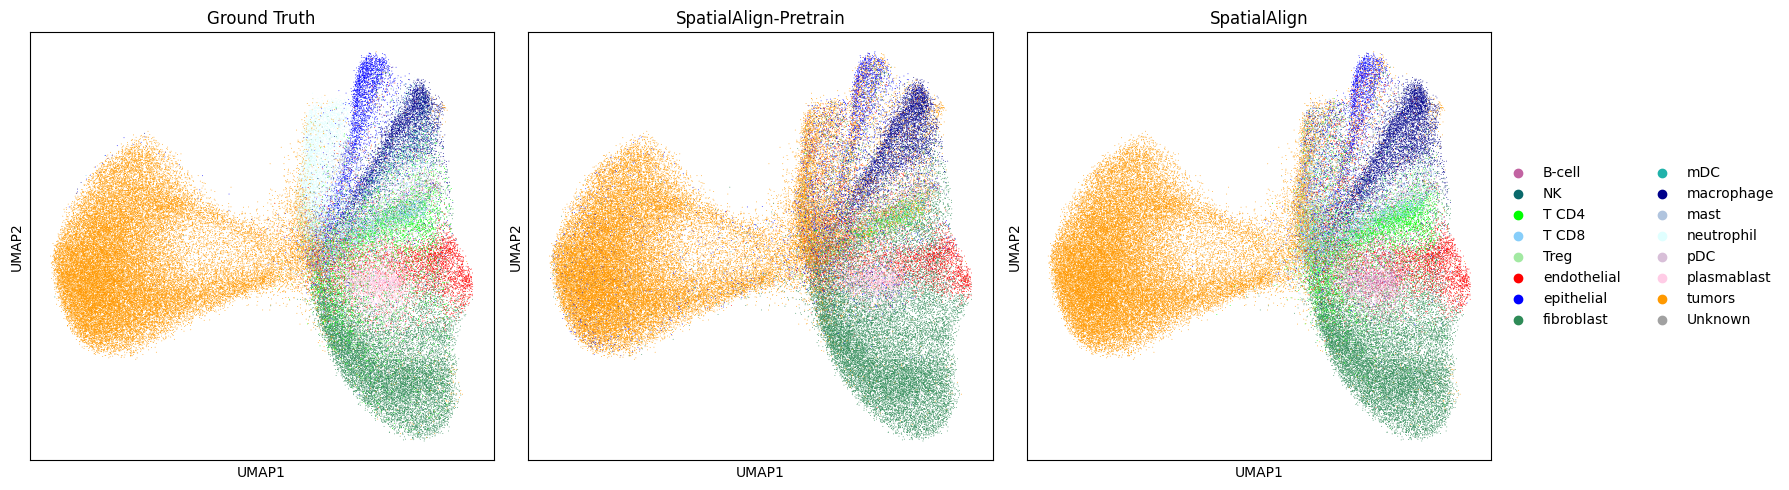

In [35]:
# Plot: Ground Truth, SpatialAlign-Pretrain (Stage1), SpatialAlign (Stage2)
import matplotlib.pyplot as plt

CLASSES = [
    'B-cell', 'NK', 'T CD4', 'T CD8', 'Treg',
    'endothelial', 'epithelial', 'fibroblast', 'mDC', 'macrophage',
    'mast', 'neutrophil', 'pDC', 'plasmablast', 'tumors', 'Unknown'
]

COLOR_MAP = {
    'B-cell': "#C263A2", 'NK': "#0A696B", 'T CD4': '#00FF00', 'T CD8': '#87CEFA',
    'Treg': "#A2E9A2", 'endothelial': '#FF0000', 'epithelial': '#0000FF',
    'fibroblast': '#2E8B57', 'mDC': '#20B2AA', 'macrophage': '#00008B',
    'mast': '#B0C4DE', 'neutrophil': '#E0FFFF', 'pDC': '#D8BFD8',
    'plasmablast': "#FFCCE6", 'tumors': "#FF9900", 'Unknown': "#A1A1A1"
}

def apply_palette(adata, key):
    labels = adata.obs[key].astype(str).str.strip()
    # Map labels not in CLASSES to Unknown
    labels = labels.where(labels.isin(CLASSES), 'Unknown')
    adata.obs[key] = pd.Categorical(labels, categories=CLASSES, ordered=True)
    return [COLOR_MAP[c] for c in adata.obs[key].cat.categories]

# Require UMAP for plotting
if "X_umap" in adata_st.obsm:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    apply_palette(adata_st, key='celltype')
    pal_gt = [COLOR_MAP[c] for c in adata_st.obs['celltype'].cat.categories]
    sc.pl.umap(adata_st, color='celltype', palette=pal_gt, ax=axes[0], title='Ground Truth',
               frameon=True, size=1.5, legend_loc='none', show=False)

    apply_palette(adata_st, key='pseudo_label_stage1')
    pal_s1 = [COLOR_MAP[c] for c in adata_st.obs['pseudo_label_stage1'].cat.categories]
    sc.pl.umap(adata_st, color='pseudo_label_stage1', palette=pal_s1, ax=axes[1], title='SpatialAlign-Pretrain',
               frameon=True, size=1.5, legend_loc='none', show=False)

    apply_palette(adata_st, key='pseudo_label')
    pal_s2 = [COLOR_MAP[c] for c in adata_st.obs['pseudo_label'].cat.categories]
    sc.pl.umap(adata_st, color='pseudo_label', palette=pal_s2, ax=axes[2], title='SpatialAlign',
               frameon=True, size=1.5, legend_loc='right margin', legend_fontsize=10, show=False)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'comparison_umap.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("X_umap not found; provide umap_csv_path to enable visualization")

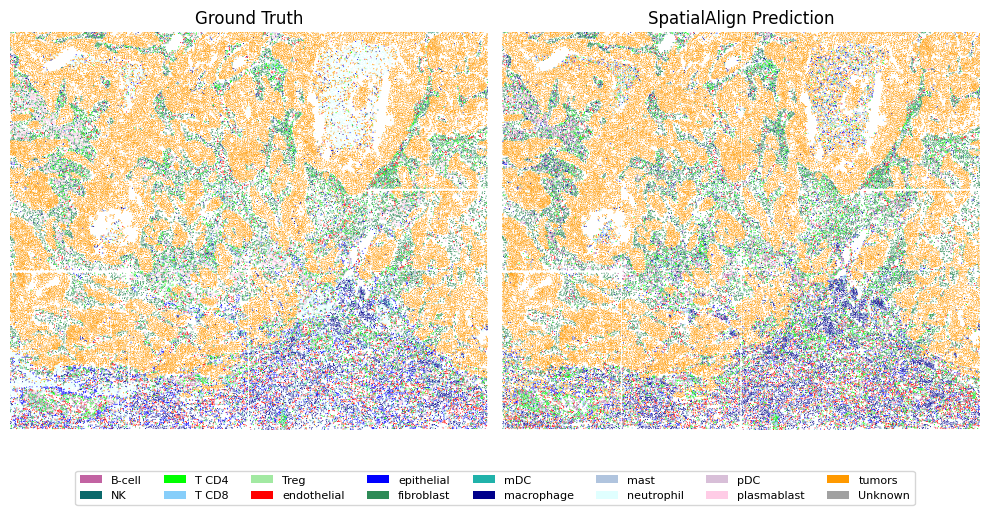

In [38]:
# Spatial scatter plot: Ground Truth vs SpatialAlign Prediction
import matplotlib.pyplot as plt

CLASSES = [
    'B-cell', 'NK', 'T CD4', 'T CD8', 'Treg',
    'endothelial', 'epithelial', 'fibroblast', 'mDC', 'macrophage',
    'mast', 'neutrophil', 'pDC', 'plasmablast', 'tumors', 'Unknown'
]
COLOR_MAP = {
    'B-cell': "#C263A2", 'NK': "#0A696B", 'T CD4': '#00FF00', 'T CD8': '#87CEFA',
    'Treg': "#A2E9A2", 'endothelial': '#FF0000', 'epithelial': '#0000FF',
    'fibroblast': '#2E8B57', 'mDC': '#20B2AA', 'macrophage': '#00008B',
    'mast': '#B0C4DE', 'neutrophil': '#E0FFFF', 'pDC': '#D8BFD8',
    'plasmablast': "#FFCCE6", 'tumors': "#FF9900", 'Unknown': "#A1A1A1"
}

def plot_spatial_scatter(adata, label_key, ax, color_map=None):
    """Plot spatial scatter on given ax"""
    color_map = color_map or COLOR_MAP
    labels = adata.obs[label_key].astype(str).str.strip()
    uniq = labels.unique()
    cats = list(CLASSES) + [c for c in uniq if c not in CLASSES]
    adata.obs["_plot_label"] = pd.Categorical(labels, categories=cats, ordered=True)
    colors = adata.obs["_plot_label"].map(lambda c: color_map.get(c, "#808080") if pd.notna(c) else "#808080")

    x = adata.obs["CenterX_global_px"].to_numpy()
    y = adata.obs["CenterY_global_px"].to_numpy()

    ax.scatter(x, y, c=colors, s=0.6, linewidths=0)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())
    ax.margins(0)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
        spine.set_visible(False)
    return adata.obs["_plot_label"].cat.categories

# Requires adata_st with CenterX_global_px; if UMAP subset was applied, use pre-subset adata
# If adata_st still has spatial coords after UMAP subset, use current adata_st
if "CenterX_global_px" in adata_st.obs.columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    plot_spatial_scatter(adata_st, "celltype", axes[0])
    axes[0].set_title("Ground Truth")

    plot_spatial_scatter(adata_st, "pseudo_label", axes[1])
    axes[1].set_title("SpatialAlign Prediction")

    # Shared legend: bottom center
    fig.legend(handles=[plt.matplotlib.patches.Patch(facecolor=COLOR_MAP.get(c, "#808080"), label=c) for c in CLASSES],
               loc='lower center', ncol=8, bbox_to_anchor=(0.5, -0.02), fontsize=8)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(os.path.join(output_dir, 'comparison_spatial.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("adata_st does not contain CenterX_global_px; cannot plot spatial scatter")

In [ ]:
adata_st

AnnData object with n_obs × n_vars = 85904 × 952
    obs: 'fov', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'celltype', 'pseudo_label', 'pseudo_confidence', 'pseudo_label_stage1'
    uns: 'log1p', 'celltype_colors', 'pseudo_label_stage1_colors', 'pseudo_label_colors'
    obsm: 'spatial', 'X_umap'